# Neural Networks Deep Dive (Intro to Gen AI, Note 02)

Companion notebook for `02-Neural-Networks-Fundamentals.md`. It extends `neural_networks_from_scratch.ipynb` (which trains a tiny XOR network) to a **real multi-class MLP written only in NumPy**. Only NumPy, scikit-learn (for datasets) and matplotlib are needed.

| Part | Topic |
|---|---|
| A | Building blocks and an `MLP` class (column convention, W is out × in), mini-batch training |
| B | Verifying the note's worked examples (2-2-1 backward pass, 3-class softmax gradient) |
| C | Gradient check: backprop vs finite differences |
| D | Training on `load_digits` (8×8 handwritten digits) to over 90% test accuracy |
| E | Activation comparison (sigmoid vs tanh vs ReLU) with training curves |
| F | Vanishing gradients: per-layer gradient norms in a 10-layer network |
| G | Initialisation experiment: zeros vs small random vs large vs Xavier vs He |
| H | Decision boundary on `make_moons` |
| I | Universal approximation in 1D (ReLU hat functions) and why depth helps (tent map) |
| J | Every other number quoted in the note: sigmoid 2-2-1 example, vanishing products, Xavier/He variances, parameter counts, Transformer MLP share, fraud base rate |

## Part A — Building blocks and the MLP class

Every batch is stored with **examples as columns**: `X` has shape `(n_features, B)`, so a layer is `A = W @ H + b` with `W` of shape (n_out × n_in), exactly as in the note. The backward pass implements the recursion δ⁽ˡ⁾ = (W⁽ˡ⁺¹⁾ᵀ δ⁽ˡ⁺¹⁾) ⊙ g′(a⁽ˡ⁾), with δ at the softmax output equal to (ŷ − y)/B.

In [1]:
import matplotlib.pyplot as plt
import numpy as np, time
from sklearn.datasets import load_digits, make_moons
from sklearn.model_selection import train_test_split
np.set_printoptions(precision=4, suppress=True)

ACT = {
 "sigmoid": (lambda z: 1/(1+np.exp(-z)), lambda z, h: h*(1-h)),
 "tanh":    (np.tanh,                    lambda z, h: 1-h**2),
 "relu":    (lambda z: np.maximum(0, z), lambda z, h: (z > 0).astype(z.dtype)),
}
def softmax(Z):                       # Z: (K, B), columns are examples
    Z = Z - Z.max(axis=0, keepdims=True)
    E = np.exp(Z); return E / E.sum(axis=0, keepdims=True)

def init_params(sizes, scheme, rng):
    Ws, bs = [], []
    for n_in, n_out in zip(sizes[:-1], sizes[1:]):
        if scheme == "zeros":   W = np.zeros((n_out, n_in))
        elif scheme == "small": W = 0.01 * rng.standard_normal((n_out, n_in))
        elif scheme == "xavier":W = rng.standard_normal((n_out, n_in)) * np.sqrt(2/(n_in+n_out))
        elif scheme == "he":    W = rng.standard_normal((n_out, n_in)) * np.sqrt(2/n_in)
        elif scheme == "large": W = rng.standard_normal((n_out, n_in))
        Ws.append(W); bs.append(np.zeros((n_out, 1)))
    return Ws, bs

class MLP:
    """Column convention: W[l] has shape (n_out, n_in); a batch X has shape (n_features, B)."""
    def __init__(self, sizes, act="relu", init="he", seed=0):
        self.rng = np.random.default_rng(seed)
        self.sizes, self.act = sizes, act
        self.g, self.dg = ACT[act]
        self.W, self.b = init_params(sizes, init, self.rng)
    def forward(self, X):
        self.cache = [(None, X)]                       # (a, h) per layer; h0 = X
        H = X
        for l, (W, b) in enumerate(zip(self.W, self.b)):
            A = W @ H + b
            H = softmax(A) if l == len(self.W)-1 else self.g(A)
            self.cache.append((A, H))
        return H                                       # (K, B) probabilities
    def loss(self, P, Y):                              # Y one-hot (K, B)
        return -np.mean(np.sum(Y*np.log(P+1e-12), axis=0))
    def backward(self, Y):
        B = Y.shape[1]
        P = self.cache[-1][1]
        delta = (P - Y) / B                            # dL/dA at the output: (ŷ − y)/B
        gW, gb = [None]*len(self.W), [None]*len(self.W)
        for l in range(len(self.W)-1, -1, -1):
            H_prev = self.cache[l][1]
            gW[l] = delta @ H_prev.T                   # (n_out, B)(B, n_in) = (n_out, n_in)
            gb[l] = delta.sum(axis=1, keepdims=True)
            if l > 0:
                A_prev, H_prev = self.cache[l]
                delta = (self.W[l].T @ delta) * self.dg(A_prev, H_prev)
        return gW, gb
    def step(self, gW, gb, lr):
        for l in range(len(self.W)):
            self.W[l] -= lr*gW[l]; self.b[l] -= lr*gb[l]
    def predict(self, X): return self.forward(X).argmax(axis=0)

def one_hot(y, K): return np.eye(K)[:, y]

def train(model, Xtr, ytr, Xte, yte, epochs=30, lr=0.1, batch=32, verbose=False):
    K = model.sizes[-1]; n = Xtr.shape[1]; hist = {"loss": [], "train_acc": [], "test_acc": []}
    for ep in range(epochs):
        perm = model.rng.permutation(n)
        for i in range(0, n, batch):
            idx = perm[i:i+batch]
            model.forward(Xtr[:, idx]); gW, gb = model.backward(one_hot(ytr[idx], K)); model.step(gW, gb, lr)
        P = model.forward(Xtr); hist["loss"].append(model.loss(P, one_hot(ytr, K)))
        hist["train_acc"].append((P.argmax(0) == ytr).mean()); hist["test_acc"].append((model.predict(Xte) == yte).mean())
        if verbose and (ep % 5 == 4 or ep == 0):
            print(f"epoch {ep+1:3d}  loss {hist['loss'][-1]:.4f}  train acc {hist['train_acc'][-1]:.4f}  test acc {hist['test_acc'][-1]:.4f}")
    return hist


# ---- data: 1797 8x8 digit images, pixel values 0..16 scaled to [0, 1] ----
digits = load_digits()
X = digits.data / 16.0; y = digits.target
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
Xtr, Xte = Xtr.T, Xte.T

print('train', Xtr.shape, ' test', Xte.shape)

train (64, 1347)  test (64, 450)


## Part B — The note's worked examples, checked

Section 11 of the note does the forward and backward pass of the slide-23 network by hand (x = (1, 2), y = 1, ReLU hidden, sigmoid output, binary cross-entropy) and one gradient step with η = 0.1.

In [2]:
sig = lambda z: 1/(1+np.exp(-z))
x = np.array([1., 2.]); yt = 1.0
W1 = np.array([[0.5, -1.], [1.5, 0.5]]); c1 = np.array([0., -1.]); W2 = np.array([2., -1.]); c2 = 0.5
def fwd(W1, c1, W2, c2):
    a1 = W1 @ x + c1; h1 = np.maximum(0, a1); a2 = W2 @ h1 + c2; yh = sig(a2)
    return a1, h1, a2, yh, -(yt*np.log(yh) + (1-yt)*np.log(1-yh))
a1, h1, a2, yh, L = fwd(W1, c1, W2, c2)
print("a1 =", a1, " h1 =", h1, " a2 =", a2, " y_hat =", round(yh, 4), " loss =", round(L, 4))
d2 = yh - yt                       # output delta (sigmoid + BCE)
gW2, gc2 = d2 * h1, d2
d1 = (W2 * d2) * (a1 > 0)          # hidden delta
gW1, gc1 = np.outer(d1, x), d1
print("delta2 =", round(d2, 4), " dL/dW2 =", gW2, " dL/dc2 =", round(gc2, 4))
print("delta1 =", d1, "\ndL/dW1 =\n", gW1, "\ndL/dc1 =", gc1)
eta = 0.1
new = (W1 - eta*gW1, c1 - eta*gc1, W2 - eta*gW2, c2 - eta*gc2)
_, _, _, yh2, L2 = fwd(*new)
print(f"after one step (eta=0.1): y_hat {yh:.4f} -> {yh2:.4f},  loss {L:.4f} -> {L2:.4f}")

a1 = [-1.5  1.5]  h1 = [0.  1.5]  a2 = -1.0  y_hat = 0.2689  loss = 1.3133
delta2 = -0.7311  dL/dW2 = [-0.     -1.0966]  dL/dc2 = -0.7311
delta1 = [-0.      0.7311] 
dL/dW1 =
 [[-0.     -0.    ]
 [ 0.7311  1.4621]] 
dL/dc1 = [-0.      0.7311]
after one step (eta=0.1): y_hat 0.2689 -> 0.4081,  loss 1.3133 -> 0.8963


In [3]:
z = np.array([2.0, 1.0, 0.1]); y3 = np.array([0., 1., 0.])     # true class = 2nd
p = softmax(z[:, None])[:, 0]
print("softmax      :", p)
print("cross-entropy:", -np.log(p[1]))
print("dL/dz = p - y:", p - y3)
# finite-difference check of the same gradient
eps = 1e-6
num = [(-np.log(softmax((z + eps*e)[:, None])[1, 0]) + np.log(softmax((z - eps*e)[:, None])[1, 0])) / (2*eps) for e in np.eye(3)]
print("numerical    :", np.array(num))

softmax      : [0.659  0.2424 0.0986]
cross-entropy: 1.4170300162778335
dL/dz = p - y: [ 0.659  -0.7576  0.0986]
numerical    : [ 0.659  -0.7576  0.0986]


## Part C — Gradient check

Compare every analytic gradient with the central difference (L(θ+ε) − L(θ−ε)) / 2ε on a small network and a small batch. A relative error around 1e-7 or below means the backward pass is correct.

In [4]:
def grad_check(act, seed=1, eps=1e-5):
    m = MLP([5, 4, 3, 3], act=act, init="xavier", seed=seed)
    rng = np.random.default_rng(seed)
    Xs = rng.standard_normal((5, 7)); Ys = one_hot(rng.integers(0, 3, 7), 3)
    m.forward(Xs); gW, gb = m.backward(Ys)
    worst = 0.0
    for params, grads in [(m.W, gW), (m.b, gb)]:
        for P, G in zip(params, grads):
            it = np.nditer(P, flags=["multi_index"])
            for _ in it:
                i = it.multi_index; old = P[i]
                P[i] = old + eps; Lp = m.loss(m.forward(Xs), Ys)
                P[i] = old - eps; Lm = m.loss(m.forward(Xs), Ys)
                P[i] = old
                num = (Lp - Lm) / (2*eps)
                worst = max(worst, abs(num - G[i]) / max(1e-12, abs(num) + abs(G[i])))
    return worst
for act in ["sigmoid", "tanh", "relu"]:
    print(f"{act:8s} max relative error = {grad_check(act):.2e}")

sigmoid  max relative error = 3.07e-08
tanh     max relative error = 1.11e-09
relu     max relative error = 3.25e-09


## Part D — Training on handwritten digits

`load_digits` has 1,797 images of 8×8 pixels (a small cousin of MNIST). Architecture 64 → 64 → 10 (ReLU, He init, softmax output), mini-batches of 32, plain SGD with learning rate 0.1, 30 epochs.

In [5]:
model = MLP([64, 64, 10], act="relu", init="he", seed=0)
n_params = sum(W.size + b.size for W, b in zip(model.W, model.b))
print("parameters:", n_params)
hist = train(model, Xtr, ytr, Xte, yte, epochs=30, lr=0.1, batch=32, verbose=True)
print(f"\nfinal test accuracy: {hist['test_acc'][-1]:.4f}")

parameters: 4810
epoch   1  loss 1.4369  train acc 0.5746  test acc 0.5622
epoch   5  loss 0.2959  train acc 0.9428  test acc 0.9156
epoch  10  loss 0.1680  train acc 0.9621  test acc 0.9511
epoch  15  loss 0.1421  train acc 0.9614  test acc 0.9356
epoch  20  loss 0.0937  train acc 0.9792  test acc 0.9689
epoch  25  loss 0.0766  train acc 0.9829  test acc 0.9600


epoch  30  loss 0.0652  train acc 0.9874  test acc 0.9689

final test accuracy: 0.9689


confusion matrix (rows = true digit, cols = predicted):
[[43  0  0  0  2  0  0  0  0  0]
 [ 1 45  0  0  0  0  0  0  0  0]
 [ 0  1 43  0  0  0  0  0  0  0]
 [ 0  0  0 46  0  0  0  0  0  0]
 [ 0  0  0  0 45  0  0  0  0  0]
 [ 0  0  0  0  0 44  0  0  0  2]
 [ 0  0  0  0  0  0 44  0  1  0]
 [ 0  0  0  0  1  0  0 44  0  0]
 [ 0  4  0  0  0  0  0  0 39  0]
 [ 0  0  0  0  1  0  0  1  0 43]]


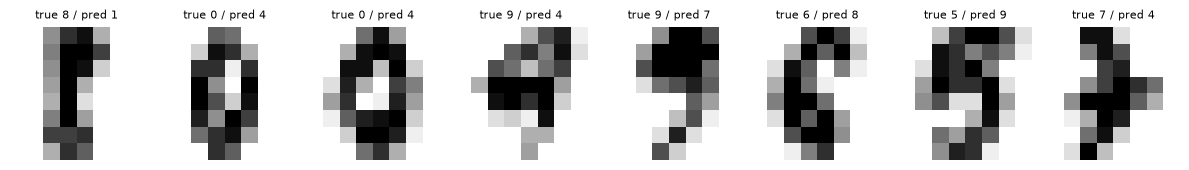

In [6]:
from sklearn.metrics import confusion_matrix
pred = model.predict(Xte)
print("confusion matrix (rows = true digit, cols = predicted):")
print(confusion_matrix(yte, pred))
wrong = np.where(pred != yte)[0][:8]
fig, axes = plt.subplots(1, len(wrong), figsize=(1.5*len(wrong), 1.8))
for ax, i in zip(np.atleast_1d(axes), wrong):
    ax.imshow(Xte[:, i].reshape(8, 8), cmap="gray_r"); ax.set_title(f"true {yte[i]} / pred {pred[i]}", fontsize=8); ax.axis("off")
plt.tight_layout(); plt.show()

## Part E — Activation comparison

Same deeper network (64 → 64 → 64 → 64 → 10), same seed, same learning rate (0.05), 40 epochs; only the hidden activation changes. Sigmoid uses Xavier init, tanh Xavier, ReLU He.

sigmoid  loss after 1/10/40 epochs: 2.325 / 2.315 / 2.290   test acc 0.1000


tanh     loss after 1/10/40 epochs: 1.405 / 0.217 / 0.039   test acc 0.9489


relu     loss after 1/10/40 epochs: 1.391 / 0.627 / 0.011   test acc 0.9778


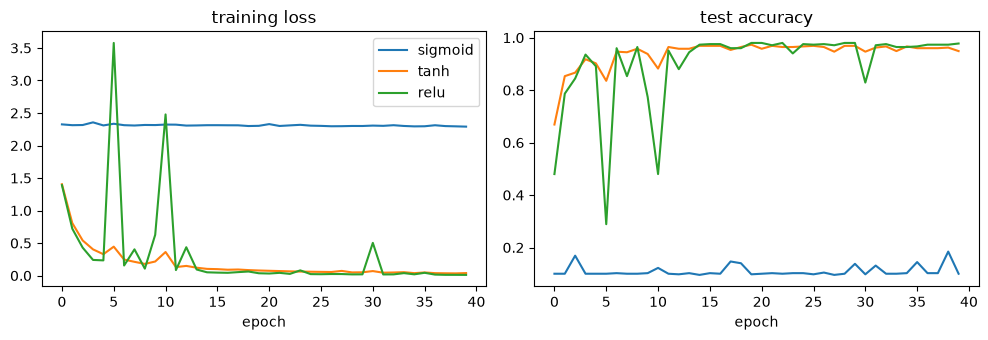

In [7]:
curves = {}
for act, init in [("sigmoid", "xavier"), ("tanh", "xavier"), ("relu", "he")]:
    m = MLP([64, 64, 64, 64, 10], act=act, init=init, seed=0)
    curves[act] = train(m, Xtr, ytr, Xte, yte, epochs=40, lr=0.05)
    h = curves[act]
    print(f"{act:8s} loss after 1/10/40 epochs: {h['loss'][0]:.3f} / {h['loss'][9]:.3f} / {h['loss'][-1]:.3f}   test acc {h['test_acc'][-1]:.4f}")
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
for act, h in curves.items():
    ax[0].plot(h["loss"], label=act); ax[1].plot(h["test_acc"], label=act)
ax[0].set_title("training loss"); ax[0].set_xlabel("epoch"); ax[1].set_title("test accuracy"); ax[1].set_xlabel("epoch")
ax[0].legend(); plt.tight_layout(); plt.show()

## Part F — Vanishing gradients, measured

A 10-hidden-layer network (width 64) at initialisation, one batch of digits. We print the norm of ∂L/∂W for each layer. With sigmoid the gradient shrinks by a large factor every layer going backwards; with ReLU + He it stays roughly level.

sigmoid+xavier  layer1 4.04e-07  layer11 6.21e-01  ratio first/last = 6.51e-07
tanh+xavier     layer1 3.37e-01  layer11 2.28e-01  ratio first/last = 1.47e+00
relu+he         layer1 7.06e-01  layer11 9.03e-01  ratio first/last = 7.82e-01


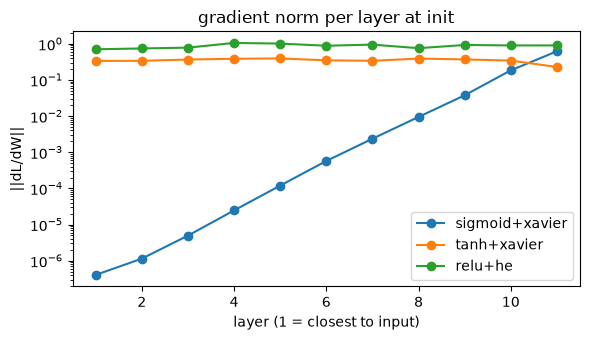

In [8]:
def layer_grad_norms(act, init, depth=10, width=64, seed=0):
    m = MLP([64] + [width]*depth + [10], act=act, init=init, seed=seed)
    m.forward(Xtr[:, :256]); gW, _ = m.backward(one_hot(ytr[:256], 10))
    return np.array([np.linalg.norm(g) for g in gW])
norms = {f"{a}+{i}": layer_grad_norms(a, i) for a, i in [("sigmoid", "xavier"), ("tanh", "xavier"), ("relu", "he")]}
for k, v in norms.items():
    print(f"{k:15s} layer1 {v[0]:.2e}  layer11 {v[-1]:.2e}  ratio first/last = {v[0]/v[-1]:.2e}")
plt.figure(figsize=(6, 3.5))
for k, v in norms.items(): plt.semilogy(range(1, len(v)+1), v, "o-", label=k)
plt.xlabel("layer (1 = closest to input)"); plt.ylabel("||dL/dW||"); plt.legend(); plt.title("gradient norm per layer at init"); plt.tight_layout(); plt.show()

## Part G — Initialisation experiment

A 6-hidden-layer ReLU network (width 64). First, the standard deviation of each layer's activations at initialisation; then 30 epochs of training (lr 0.05) for each scheme. `large` (std 1) is only inspected, not trained: its activations explode.

In [9]:
schemes = ["zeros", "small", "large", "xavier", "he"]
for s in schemes:
    m = MLP([64] + [64]*6 + [10], act="relu", init=s, seed=0)
    m.forward(Xtr)
    stds = [m.cache[l][1].std() for l in range(1, 7)]
    print(f"{s:7s} hidden-activation std by layer:", " ".join(f"{v:9.2e}" for v in stds))

zeros   hidden-activation std by layer:  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
small   hidden-activation std by layer:  2.57e-02  1.36e-03  8.74e-05  5.50e-06  2.87e-07  1.83e-08
large   hidden-activation std by layer:  2.57e+00  1.36e+01  8.74e+01  5.50e+02  2.87e+03  1.83e+04
xavier  hidden-activation std by layer:  3.21e-01  2.13e-01  1.71e-01  1.34e-01  8.77e-02  7.00e-02
he      hidden-activation std by layer:  4.54e-01  4.26e-01  4.83e-01  5.37e-01  4.96e-01  5.60e-01


In [10]:
init_hist = {}
for s in ["zeros", "small", "xavier", "he"]:
    m = MLP([64] + [64]*6 + [10], act="relu", init=s, seed=0)
    init_hist[s] = train(m, Xtr, ytr, Xte, yte, epochs=30, lr=0.05)
    h = init_hist[s]
    print(f"{s:7s} loss epoch1 {h['loss'][0]:.4f} -> epoch30 {h['loss'][-1]:.4f}   test acc {h['test_acc'][-1]:.4f}")
# symmetry: with zero init every hidden unit in a layer has identical weights forever
m = MLP([64, 16, 10], act="relu", init="zeros", seed=0); train(m, Xtr, ytr, Xte, yte, epochs=3, lr=0.05)
print("zeros init, distinct rows in W1 after training:", len(np.unique(m.W[0].round(10), axis=0)))

zeros   loss epoch1 2.3026 -> epoch30 2.3026   test acc 0.1022


small   loss epoch1 2.3026 -> epoch30 2.3026   test acc 0.1000


xavier  loss epoch1 2.2255 -> epoch30 0.0046   test acc 0.9756


he      loss epoch1 2.1553 -> epoch30 0.0017   test acc 0.9711
zeros init, distinct rows in W1 after training: 1


## Part H — Decision boundary on make_moons

Two interleaving half-moons (not linearly separable). A 2 → 16 → 16 → 2 ReLU MLP vs the same network with **identity** activation (which collapses to a linear model, Section 8 of the note).

identity test accuracy 0.8556


relu     test accuracy 0.9500


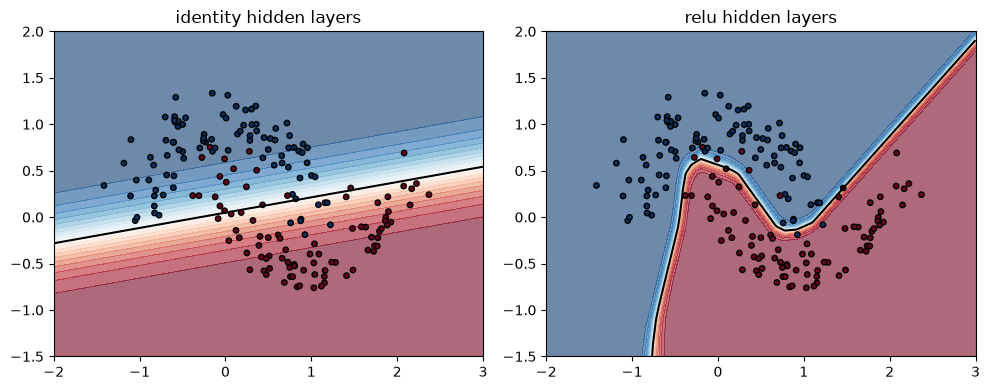

In [11]:
Xm, ym = make_moons(n_samples=600, noise=0.2, random_state=0)
Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(Xm, ym, test_size=0.3, random_state=0)
ACT["identity"] = (lambda z: z, lambda z, h: np.ones_like(z))
res = {}
for act in ["identity", "relu"]:
    m = MLP([2, 16, 16, 2], act=act, init="he", seed=0)
    hh = train(m, Xm_tr.T, ym_tr, Xm_te.T, ym_te, epochs=200, lr=0.1, batch=32)
    res[act] = m
    print(f"{act:8s} test accuracy {hh['test_acc'][-1]:.4f}")
xx, yy = np.meshgrid(np.linspace(-2, 3, 300), np.linspace(-1.5, 2, 300))
grid = np.c_[xx.ravel(), yy.ravel()].T
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (act, m) in zip(axes, res.items()):
    Z = m.forward(grid)[1].reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=20, cmap="RdBu_r", alpha=0.6); ax.contour(xx, yy, Z, levels=[0.5], colors="k")
    ax.scatter(*Xm_te.T, c=ym_te, cmap="RdBu_r", edgecolor="k", s=15); ax.set_title(f"{act} hidden layers")
plt.tight_layout(); plt.show()

## Part I — Universal approximation in 1D, and why depth helps

**I.1** Any continuous function on [0, 1] can be matched at N+1 knots by a one-hidden-layer ReLU network with N hidden units (piecewise-linear interpolation). The maximum error shrinks as N grows.

**I.2** The tent map t(x) = 2·ReLU(x) − 4·ReLU(x − 0.5) uses 2 ReLUs. Composing it k times (depth k, 2k ReLUs) produces 2ᵏ linear pieces, while a one-hidden-layer ReLU net with m units has at most m + 1 pieces on the line.

In [12]:
f = lambda x: np.sin(2*np.pi*x) + 0.5*x
def relu_interp(N):
    knots = np.linspace(0, 1, N+1); vals = f(knots)
    slopes = np.diff(vals) / np.diff(knots)
    coef = np.r_[slopes[0], np.diff(slopes)]          # output weights of the N hidden units
    return lambda x: vals[0] + sum(c*np.maximum(0, x - k) for c, k in zip(coef, knots[:-1]))
xs = np.linspace(0, 1, 2001)
for N in [2, 4, 8, 16, 32, 64]:
    print(f"N = {N:3d} hidden ReLUs: max |f - net| = {np.max(np.abs(f(xs) - relu_interp(N)(xs))):.4f}")

N =   2 hidden ReLUs: max |f - net| = 1.0000
N =   4 hidden ReLUs: max |f - net| = 0.2105
N =   8 hidden ReLUs: max |f - net| = 0.0704
N =  16 hidden ReLUs: max |f - net| = 0.0188
N =  32 hidden ReLUs: max |f - net| = 0.0048
N =  64 hidden ReLUs: max |f - net| = 0.0012


In [13]:
tent = lambda x: 2*np.maximum(0, x) - 4*np.maximum(0, x - 0.5)
xs = np.linspace(0, 1, 2**14 + 1)
for k in [1, 2, 3, 5, 10]:
    v = xs.copy()
    for _ in range(k): v = tent(v)
    slopes = np.sign(np.diff(v) / np.diff(xs))
    pieces = 1 + np.count_nonzero(np.diff(slopes))
    print(f"depth {k:2d}: {2*k:3d} ReLUs, {pieces:5d} linear pieces  -> a shallow net needs >= {pieces-1} ReLUs")

depth  1:   2 ReLUs,     2 linear pieces  -> a shallow net needs >= 1 ReLUs
depth  2:   4 ReLUs,     4 linear pieces  -> a shallow net needs >= 3 ReLUs
depth  3:   6 ReLUs,     8 linear pieces  -> a shallow net needs >= 7 ReLUs
depth  5:  10 ReLUs,    32 linear pieces  -> a shallow net needs >= 31 ReLUs
depth 10:  20 ReLUs,  1024 linear pieces  -> a shallow net needs >= 1023 ReLUs


## Part J — Numbers quoted in the note

J.1 The fully sigmoid 2-2-1 worked example (Section 11.4 of the note): forward, backward, one update with η = 0.5, checked against finite differences.
J.2 Vanishing/exploding products. J.3 Xavier/He variances, plus an empirical check of the variance argument. J.4 Parameter counts, including the share of a Transformer block taken by its MLP. J.5 Base-rate arithmetic for the card-fraud case study.

In [14]:
# J.1 sigmoid 2-2-1 network, binary cross-entropy, eta = 0.5
x = np.array([1.0, 0.5]); yt = 1.0
W1 = np.array([[0.2, -0.3], [0.4, 0.1]]); b1 = np.array([0.1, -0.1]); W2 = np.array([0.5, -0.4]); b2 = 0.2
def fwd_s(W1, b1, W2, b2):
    a1 = W1 @ x + b1; h1 = sig(a1); a2 = W2 @ h1 + b2; yh = sig(a2)
    return a1, h1, a2, yh, -np.log(yh)
a1, h1, a2, yh, L = fwd_s(W1, b1, W2, b2)
print("a1 =", a1, " h1 =", h1, " a2 =", round(a2, 4), " y_hat =", round(yh, 4), " loss =", round(L, 4))
d2 = yh - yt; gW2 = d2 * h1; gb2 = d2
gp = h1 * (1 - h1); d1 = (W2 * d2) * gp; gW1 = np.outer(d1, x); gb1 = d1
print("delta2 =", round(d2, 4), " dL/dW2 =", gW2, " sigma'(a1) =", gp)
print("delta1 =", d1, "\ndL/dW1 =\n", gW1)
eta = 0.5
W1n, b1n, W2n, b2n = W1 - eta*gW1, b1 - eta*gb1, W2 - eta*gW2, b2 - eta*gb2
print("W1 new =\n", W1n, "\nb1 new =", b1n, " W2 new =", W2n, " b2 new =", round(b2n, 4))
_, _, _, yh2, L2 = fwd_s(W1n, b1n, W2n, b2n)
print(f"after one step: y_hat {yh:.4f} -> {yh2:.4f}, loss {L:.4f} -> {L2:.4f}")
th = np.r_[W1.ravel(), b1, W2, b2]
def Lth(t): return fwd_s(t[:4].reshape(2, 2), t[4:6], t[6:8], t[8])[4]
num = np.array([(Lth(th + 1e-6*e) - Lth(th - 1e-6*e)) / 2e-6 for e in np.eye(9)])
ana = np.r_[gW1.ravel(), gb1, gW2, gb2]
print("max |numerical - analytic| =", np.abs(num - ana).max())

a1 = [0.15 0.35]  h1 = [0.5374 0.5866]  a2 = 0.2341  y_hat = 0.5583  loss = 0.5829
delta2 = -0.4417  dL/dW2 = [-0.2374 -0.2591]  sigma'(a1) = [0.2486 0.2425]
delta1 = [-0.0549  0.0428] 
dL/dW1 =
 [[-0.0549 -0.0275]
 [ 0.0428  0.0214]]
W1 new =
 [[ 0.2275 -0.2863]
 [ 0.3786  0.0893]] 
b1 new = [ 0.1275 -0.1214]  W2 new = [ 0.6187 -0.2704]  b2 new = 0.4209
after one step: y_hat 0.5583 -> 0.6473, loss 0.5829 -> 0.4349
max |numerical - analytic| = 1.192245885350829e-10


In [15]:
# J.2 products of derivatives through depth
print("0.25^10 =", 0.25**10, "  0.25^20 =", 0.25**20, "  sigma'(2) =", round(sig(2)*(1-sig(2)), 4), "  sigma'(2)^10 =", (sig(2)*(1-sig(2)))**10)
print("tanh'(0.5) =", round(1-np.tanh(0.5)**2, 4), "  ^10 =", round((1-np.tanh(0.5)**2)**10, 4))
print("per-layer factor 1.1 over 50 layers =", round(1.1**50, 2), "   0.9 over 50 layers =", round(0.9**50, 5))
# J.3 Xavier / He
for n_in, n_out in [(256, 128), (400, 100), (784, 256)]:
    print(f"{n_in}->{n_out}: Xavier var {2/(n_in+n_out):.6f} (std {np.sqrt(2/(n_in+n_out)):.4f}, uniform limit {np.sqrt(6/(n_in+n_out)):.4f}),  He var {2/n_in:.6f} (std {np.sqrt(2/n_in):.4f})")
rng = np.random.default_rng(0); n = 256; Xg = rng.standard_normal((n, 10000))
for name, s in [("std 1", 1.0), ("1/n_in (LeCun)", np.sqrt(1/n)), ("2/n_in (He)", np.sqrt(2/n))]:
    A = (rng.standard_normal((256, n)) * s) @ Xg
    print(f"Var(w) = {name:15s}: Var(a) = {A.var():8.3f},  E[ReLU(a)^2] = {(np.maximum(A, 0)**2).mean():8.3f}")

0.25^10 = 9.5367431640625e-07   0.25^20 = 9.094947017729282e-13   sigma'(2) = 0.105   sigma'(2)^10 = 1.6278997858476353e-10
tanh'(0.5) = 0.7864   ^10 = 0.0905
per-layer factor 1.1 over 50 layers = 117.39    0.9 over 50 layers = 0.00515
256->128: Xavier var 0.005208 (std 0.0722, uniform limit 0.1250),  He var 0.007812 (std 0.0884)
400->100: Xavier var 0.004000 (std 0.0632, uniform limit 0.1095),  He var 0.005000 (std 0.0707)
784->256: Xavier var 0.001923 (std 0.0439, uniform limit 0.0760),  He var 0.002551 (std 0.0505)
Var(w) = std 1          : Var(a) =  255.296,  E[ReLU(a)^2] =  127.582
Var(w) = 1/n_in (LeCun) : Var(a) =    1.003,  E[ReLU(a)^2] =    0.501
Var(w) = 2/n_in (He)    : Var(a) =    2.006,  E[ReLU(a)^2] =    1.003


In [16]:
# J.4 parameter counts
count = lambda s: sum(a*b + b for a, b in zip(s[:-1], s[1:]))
for s in [[2, 2, 1], [2, 4, 1], [10, 20, 20, 3], [64, 64, 10], [784, 128, 64, 10], [784, 256, 256, 10], [784, 300, 100, 10], [30, 64, 32, 1]]:
    print(s, count(s))
for name, d, L in [("GPT-2 small", 768, 12), ("GPT-3", 12288, 96)]:
    mlp = 2*d*4*d + 4*d + d; att = 4*d*d + 4*d
    print(f"{name}: MLP/layer {mlp:,}  attention/layer {att:,}  MLP share {mlp/(mlp+att):.4f}  all blocks {L*(mlp+att):,}")
d, h = 4096, 11008
print(f"LLaMA-7B SwiGLU MLP/layer {3*d*h:,} (x32 = {32*3*d*h:,}), attention/layer {4*d*d:,}, share {3*d*h/(3*d*h+4*d*d):.4f}")
# J.5 card fraud base rate (ULB / Kaggle dataset: 492 frauds in 284,807 transactions)
br = 492/284807; rec, fpr = 0.90, 0.01
tp, fp = rec*br, fpr*(1-br)
print(f"base rate {br:.5f}; recall 0.90, FPR 0.01 -> precision {tp/(tp+fp):.4f}; per million: {1e6*br:.0f} frauds, {1e6*tp:.0f} caught, {1e6*fp:.0f} false alarms")

[2, 2, 1] 9
[2, 4, 1] 17
[10, 20, 20, 3] 703
[64, 64, 10] 4810
[784, 128, 64, 10] 109386
[784, 256, 256, 10] 269322
[784, 300, 100, 10] 266610
[30, 64, 32, 1] 4097
GPT-2 small: MLP/layer 4,722,432  attention/layer 2,362,368  MLP share 0.6666  all blocks 85,017,600
GPT-3: MLP/layer 1,208,020,992  attention/layer 604,028,928  MLP share 0.6667  all blocks 173,956,792,320
LLaMA-7B SwiGLU MLP/layer 135,266,304 (x32 = 4,328,521,728), attention/layer 67,108,864, share 0.6684
base rate 0.00173; recall 0.90, FPR 0.01 -> precision 0.1348; per million: 1727 frauds, 1555 caught, 9983 false alarms
